# DISCO Treatment Effect Demo - Synthetic Scenario

This notebook evaluates DISCO and simple baselines on the synthetic scenario generated via the CLI.

Run the scenario commands (synth, train-devices --dataset scenario, probe --dataset scenario) before executing the cells below.

```bash
# 1 Generate a scenario (with heterogeneity + noise):
python -m disco.cli.main synth --p 8 --N 20 --m 500 --alpha 0.7 --theta0 "[0.0,0.25,0.5,0.75,1.0]" --theta "[1.2,1.3,1.4,1.5,1.6,1.7,1.8]" --K 30 --tau 0.5 --lam 0.01 --mode p --base-jitter 0.3 --peer-alpha-std 0.15 --noise-std 0.05 --out experiments/results/synth_run --seed 42

# 2 Train heterogeneous models on scenario data:
python -m disco.cli.main train-devices --dataset scenario --scenario experiments/results/synth_run/scenario.npz --samples 2000 --N 20 --out experiments/synth_devices --seed 42

# 3 Produce probe trajectories matching those models:
python -m disco.cli.main probe --devices experiments/synth_devices --dataset scenario --scenario experiments/results/synth_run/scenario.npz --probes 200 --theta0 "[0.0,0.25,0.5,0.75,1.0]" --interventions experiments/configs/tabular_interventions.yaml --out experiments/results/synth_run/probes --seed 42

# 4 (Optional) Run the CLI explanations:
python -m disco.cli.main explain --devices experiments/synth_devices --probes experiments/results/synth_run/probes --dataset scenario --scenario experiments/results/synth_run/scenario.npz --targets 0 --queries 30 --interventions experiments/configs/tabular_interventions.yaml --K 30 --tau 0.5 --lam 0.01 --mode p --out experiments/results/synth_run/explain --seed 42
```

In [1]:
# Add parent directory to path
import sys
import os
sys.path.append(os.path.abspath('../..'))


In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from disco.synth.generator import SyntheticScenario
from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.interventions.tabular import FeatureAdd, FeatureScale, ClampedShift
from disco.interventions.grids import Grids
from disco.counterfactual.pmode import PModeCounterfactual
from disco.cli.main import compute_probe_trajectories
from disco.data.loaders import stack_prewindow


def load_scenario_bundle(scenario_dir: Path):
    scenario_dir = Path(scenario_dir)
    scenario = SyntheticScenario.load(scenario_dir / 'scenario.npz')
    trajectories = {}
    sample_rows = None
    probes_dir = scenario_dir / 'probes'
    if probes_dir.exists():
        for npy_path in probes_dir.glob('*.npy'):
            if npy_path.name == 'X_probe.npy':
                continue
            parts = npy_path.stem.split('_', 2)
            if len(parts) < 3:
                continue
            device_id = '{}_{}'.format(parts[0], parts[1])
            interv_name = '_'.join(parts[2:])
            data = np.load(npy_path)
            trajectories[(device_id, interv_name)] = data
            if sample_rows is None:
                sample_rows = data.shape[0]
    X_probe = scenario.X_probe
    if sample_rows is not None and sample_rows < len(X_probe):
        X_probe = X_probe[:sample_rows]
    return scenario, trajectories, X_probe


runner = DiscoRunner()
baseline_runner = BaselineRunner()
pmode_builder = PModeCounterfactual()


In [3]:
SCENARIO_DIR = Path('..').resolve() / 'results' / 'synth_run'
scenario, scenario_trajs, scenario_X_probe = load_scenario_bundle(SCENARIO_DIR)
print('Devices: {}'.format(len(scenario.devices)))
print('Probe rows: {}'.format(scenario_X_probe.shape[0]))
print('Theta0: {}'.format(scenario.theta0))
print('Theta: {}'.format(scenario.theta))


Devices: 20
Probe rows: 500
Theta0: [0.   0.25 0.5  0.75 1.  ]
Theta: [1.2 1.3 1.4 1.5 1.6 1.7 1.8]


In [27]:
INTERVENTIONS = {
    'intensity_shift': FeatureAdd(feat_idx=0, delta_max=float(scenario.theta.max()), name='intensity_shift'),
    'add_f1': FeatureAdd(feat_idx=1, delta_max=1.5, name='add_f1'),
    'scale_f2': FeatureScale(feat_idx=2, scale_max=0.5, name='scale_f2'),
    'clamped_f4': ClampedShift(feat_idx=4, shift_max=2.0, lower=-2.0, upper=2.0, name='clamped_f4'),
}

intervention_key = 'add_f1'
intervention = INTERVENTIONS[intervention_key]
print('Selected intervention: {}'.format(intervention.name))


Selected intervention: add_f1


In [28]:
grids = Grids(theta0=scenario.theta0, theta=scenario.theta)
target_class = 0
                
trajectories = compute_probe_trajectories(
    devices=scenario.devices,
    X_probe=scenario_X_probe,      # the 200-row version
    interventions=[intervention],
    theta0=scenario.theta0,
    dp_noise_std=0.0,
    seed=0,
    target_class=0,
)

output = runner.run(
    devices=scenario.devices,
    target_idx=0,
    x_star=scenario.x_star,
    X_probe=scenario_X_probe,
    trajectories=trajectories,
    grids=grids,
    intervention=intervention,
    target_class=target_class,
    mode='s',
    lam=0.01,
)
te_output = output.te_output
result = {'te_output': te_output, 'weights': output.weights}
result.update(output.diagnostics)
print('Weight L1 sum: {:.3f}'.format(np.sum(output.weights)))
print('AUC(|tau|): {:.4f}'.format(np.trapz(np.abs(te_output.tau), te_output.theta)))


Weight L1 sum: 1.000
AUC(|tau|): 0.0191


In [29]:
theta_post = te_output.theta
weights_disco = output.weights

oracle_output = baseline_runner.baseline_oracle_ground_truth(
    devices=scenario.devices,
    trajectories=trajectories,
    theta0=scenario.theta0,
    x_star=scenario.x_star,
    grids=grids,
    intervention=intervention,
    target_idx=0,
    target_class=target_class,
)
tau_true_oracle = oracle_output.tau
w_star = np.array(oracle_output.meta["weights"])

w_avg = np.ones_like(weights_disco) / len(weights_disco)
y_syn_avg, _ = pmode_builder.build(
    w=w_avg,
    devices=scenario.devices,
    X_probe=scenario_X_probe,
    anchor_sel=result['anchor_selection'],
    x_star=scenario.x_star,
    grids=grids,
    intervention=intervention,
    target_device=scenario.devices[0],
    target_class=target_class,
)
tau_est_avg = te_output.y_t - y_syn_avg

anchor_sel = result['anchor_selection']
y_t_pre, X_peers_pre = stack_prewindow(
    trajectories=trajectories,
    target=scenario.devices[0],
    devices=scenario.devices,
    anchor_sel=anchor_sel,
    intervention=intervention,
    theta0=scenario.theta0,
)
errs = np.linalg.norm(X_peers_pre - y_t_pre[:, None], axis=0)
best_idx = int(np.argmin(errs))
w_best = np.zeros_like(weights_disco)
w_best[best_idx] = 1.0
y_syn_best, _ = pmode_builder.build(
    w=w_best,
    devices=scenario.devices,
    X_probe=scenario_X_probe,
    anchor_sel=anchor_sel,
    x_star=scenario.x_star,
    grids=grids,
    intervention=intervention,
    target_device=scenario.devices[0],
    target_class=target_class,
)
tau_est_best = te_output.y_t - y_syn_best

topk_output = baseline_runner.baseline_topk_avg(
    devices=scenario.devices,
    trajectories=trajectories,
    anchor_sel=anchor_sel,
    theta0=scenario.theta0,
    x_star=scenario.x_star,
    grids=grids,
    intervention=intervention,
    target_idx=0,
    Kp=5,
    target_class=target_class,
)
tau_est_topk = topk_output.tau

def max_abs_error(a, b):
    return float(np.max(np.abs(a - b)))

print('oracle w* L1 = {:.2f}'.format(np.sum(w_star)))
print('max |tau_true_oracle - DISCO| = {:.2e}'.format(max_abs_error(tau_true_oracle, te_output.tau)))
print('max |tau_true_oracle - best peer| = {:.2e}'.format(max_abs_error(tau_true_oracle, tau_est_best)))
print('max |tau_true_oracle - avg| = {:.2e}'.format(max_abs_error(tau_true_oracle, tau_est_avg)))
print('max |tau_true_oracle - topK| = {:.2e}'.format(max_abs_error(tau_true_oracle, tau_est_topk)))


oracle w* L1 = 1.00
max |tau_true_oracle - DISCO| = 4.63e-03
max |tau_true_oracle - best peer| = 8.47e-02
max |tau_true_oracle - avg| = 5.88e-02
max |tau_true_oracle - topK| = 1.41e-02


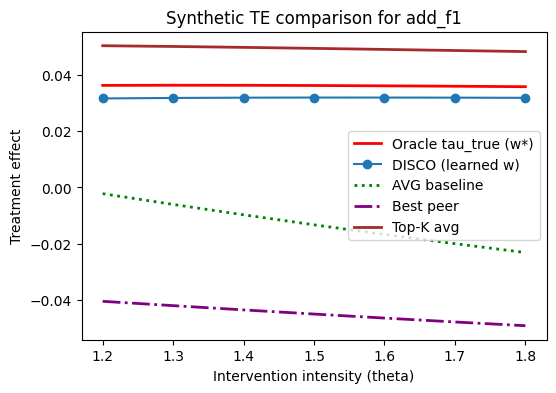

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(theta_post, tau_true_oracle, color='red', linewidth=2, label='Oracle tau_true (w*)')
ax.plot(theta_post, te_output.tau, marker='o', color='C0', label='DISCO (learned w)')
ax.plot(theta_post, tau_est_avg, color='green', linestyle=':', linewidth=2, label='AVG baseline')
ax.plot(theta_post, tau_est_best, color='purple', linestyle='-.', linewidth=2, label='Best peer')
ax.plot(theta_post, tau_est_topk, color='brown', linewidth=2, label='Top-K avg')
ax.set_xlabel('Intervention intensity (theta)')
ax.set_ylabel('Treatment effect')
ax.set_title('Synthetic TE comparison for {}'.format(intervention.name))
ax.legend()
plt.show()
